In [9]:
import numpy as np
import pandas as pd
import random
from chemevo import evolution_V1 as evo
import itertools
import os
import matplotlib.pyplot as plt


fe_mg_bin_edges = np.arange(-0.35, 0.15, 0.1)
fe_mg_centers = 0.5 * (fe_mg_bin_edges[:-1] + fe_mg_bin_edges[1:])

In [10]:
data = pd.read_csv("data_lines_with_vals.csv")

In [11]:
from chemevo import iterative_1D_method

In [20]:
etas_alter = [0, 0.1, 0.2, 0.5, 1, 2]
tau_stars_alter = [1, 2, 3, 4, 5, 10]

In [12]:
iterative_1D_method.iterative_1D_loop(data_path="data_lines_with_vals.csv", output_path="penalty_2/",
                                      n_iters=5, grid_size=0.1, grid_len=5, alpha_cc_init=0.3,
                                      alpha_Ia_init=0.4, g_cc_init=0.4, g_ratio_init=1.8)

alpha_ccs =  [0.1 0.2 0.3 0.4 0.5]
n_gals in each alpha_cc =  300
n_gals total =  1500
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
iter = 0
best alpha_cc = 0.0999999999999999
alpha_Ias =  [0.2 0.3 0.4 0.5 0.6]
n_gals in each alpha_Ia =  300
n_gals total =  900
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
iter = 0
best

In [23]:
best_per_iter = pd.read_csv("penalty_2/best_parameters_per_iteration.csv")
best_per_iter

,iteration,best_alpha_cc,best_alpha_Ia,best_g_cc,best_g_ratio
0,0,0.3,0.4,0.4,1.8
1,0,0.3,0.4,0.4,1.8
2,0,0.3,0.4,0.4,1.8
3,0,0.3,0.4,0.4,1.7
4,1,0.3,0.4,0.4,1.7
5,1,0.3,0.4,0.4,1.7
6,1,0.3,0.4,0.4,1.7
7,1,0.3,0.4,0.4,1.7
8,2,0.3,0.4,0.4,1.7
9,2,0.3,0.4,0.4,1.7


In [24]:
folder_path = "penalty_2/"

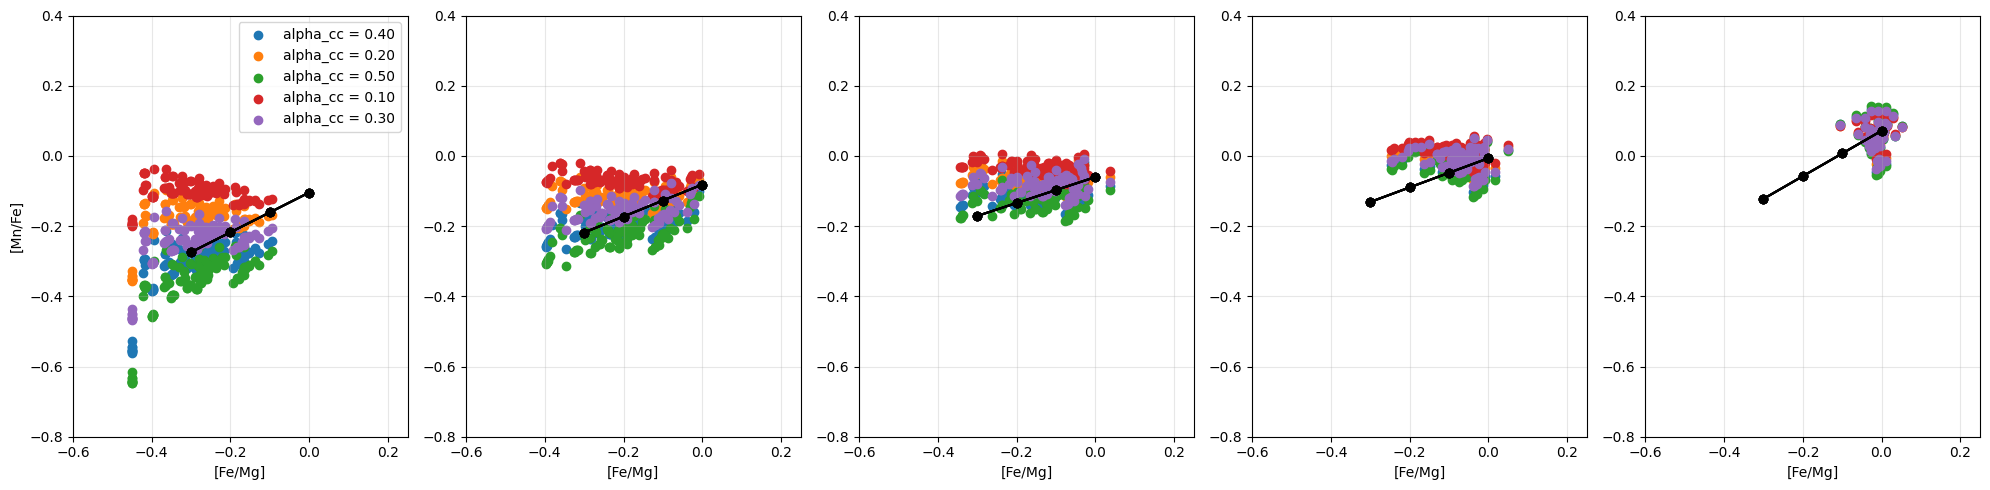

In [25]:
filepath_list = []
output_dfs = []

for filename in os.listdir(folder_path):
    if filename.startswith("alpha_cc_iter0") and filename.endswith(".csv"):
        filepath_list.append(folder_path+filename)
        df = pd.read_csv(folder_path+filename)
        output_dfs.append(df)


plt.figure(figsize=(20,5))

for i in range(len(output_dfs)):
    model_df = output_dfs[i]
    mg_h_bins = model_df['mg_h_bin'].unique()
    for j in range(len(mg_h_bins)):
        mg_h_bin = mg_h_bins[j]
        model_subset = model_df[np.isclose(model_df['mg_h_bin'], mg_h_bin)]
        data_subset = data[np.isclose(data['mg_h_bin_center'], mg_h_bin)]
        data_line_xs = fe_mg_centers
        data_line_ys = data_subset['slope_mn_fe'].iloc[0] * fe_mg_centers + data_subset['intercept_mn_fe'].iloc[0]
        plt.subplot(1,5,j+1)
        plt.plot(data_line_xs, data_line_ys, marker = 'o', color = 'black')
        plt.scatter(model_subset['fe_mg'], model_subset['mn_fe'], label = f'alpha_cc = {model_subset['alpha_cc'].iloc[0]:.2f}')
        plt.xlim(-0.60, 0.25)
        plt.ylim(-0.8, 0.40)
        plt.grid(True, alpha = 0.3)
        plt.xlabel("[Fe/Mg]")
        if j == 0:
            plt.ylabel("[Mn/Fe]")
            plt.legend()

plt.tight_layout()
plt.show()

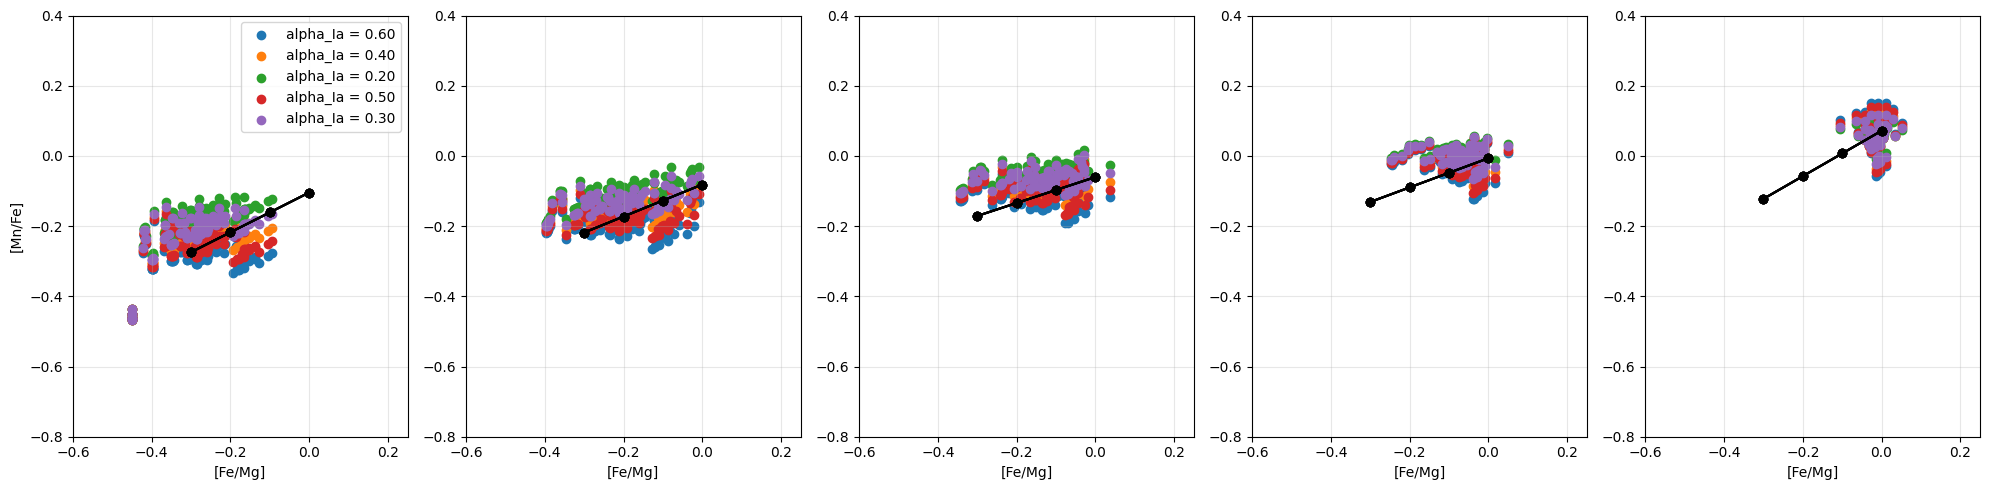

In [26]:
filepath_list = []
output_dfs = []

for filename in os.listdir(folder_path):
    if filename.startswith("alpha_Ia_iter0") and filename.endswith(".csv"):
        filepath_list.append(folder_path+filename)
        df = pd.read_csv(folder_path+filename)
        output_dfs.append(df)


plt.figure(figsize=(20,5))

for i in range(len(output_dfs)):
    model_df = output_dfs[i]
    mg_h_bins = model_df['mg_h_bin'].unique()
    for j in range(len(mg_h_bins)):
        mg_h_bin = mg_h_bins[j]
        model_subset = model_df[np.isclose(model_df['mg_h_bin'], mg_h_bin)]
        data_subset = data[np.isclose(data['mg_h_bin_center'], mg_h_bin)]
        data_line_xs = fe_mg_centers
        data_line_ys = data_subset['slope_mn_fe'].iloc[0] * fe_mg_centers + data_subset['intercept_mn_fe'].iloc[0]
        plt.subplot(1,5,j+1)
        plt.plot(data_line_xs, data_line_ys, marker = 'o', color = 'black')
        plt.scatter(model_subset['fe_mg'], model_subset['mn_fe'], label = f'alpha_Ia = {model_subset['alpha_Ia'].iloc[0]:.2f}')
        plt.xlim(-0.60, 0.25)
        plt.ylim(-0.8, 0.40)
        plt.grid(True, alpha = 0.3)
        plt.xlabel("[Fe/Mg]")
        if j == 0:
            plt.ylabel("[Mn/Fe]")
            plt.legend()

plt.tight_layout()
plt.show()

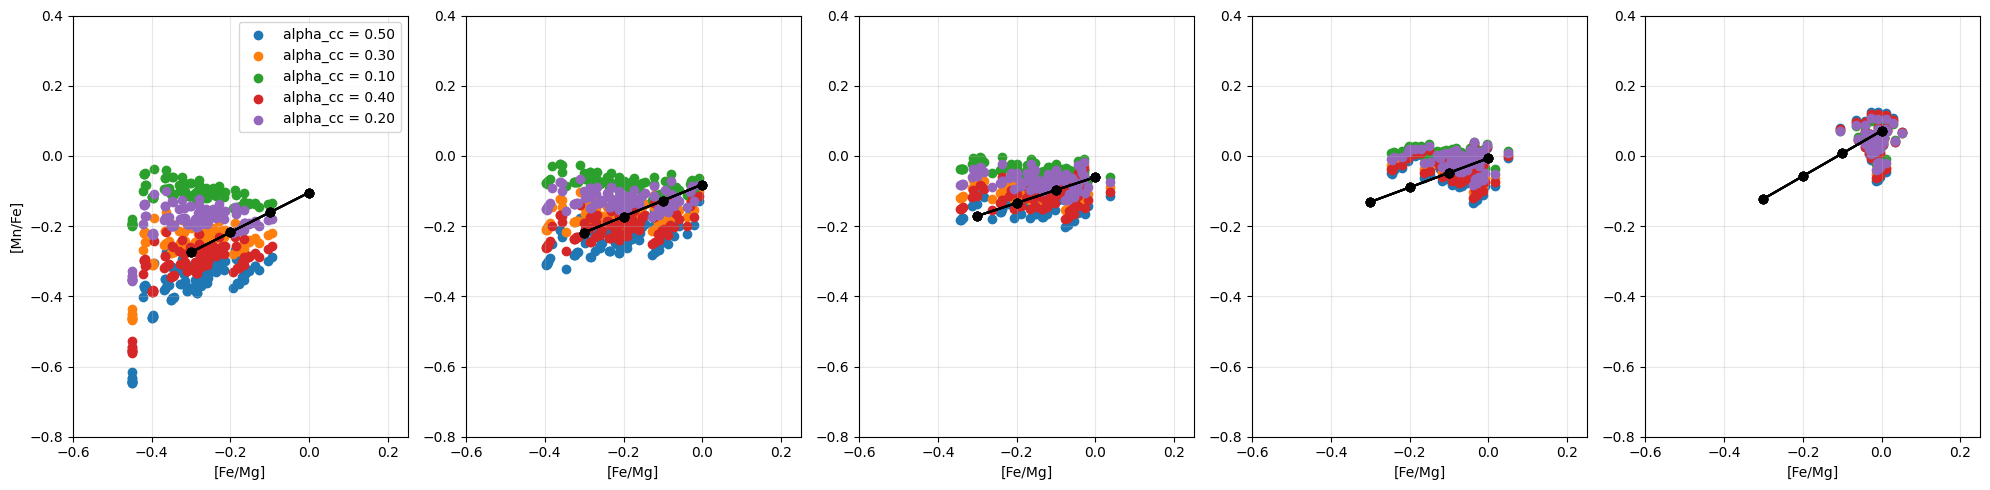

In [27]:
filepath_list = []
output_dfs = []

for filename in os.listdir(folder_path):
    if filename.startswith("alpha_cc_iter1") and filename.endswith(".csv"):
        filepath_list.append(folder_path+filename)
        df = pd.read_csv(folder_path+filename)
        output_dfs.append(df)


plt.figure(figsize=(20,5))

for i in range(len(output_dfs)):
    model_df = output_dfs[i]
    mg_h_bins = model_df['mg_h_bin'].unique()
    for j in range(len(mg_h_bins)):
        mg_h_bin = mg_h_bins[j]
        model_subset = model_df[np.isclose(model_df['mg_h_bin'], mg_h_bin)]
        data_subset = data[np.isclose(data['mg_h_bin_center'], mg_h_bin)]
        data_line_xs = fe_mg_centers
        data_line_ys = data_subset['slope_mn_fe'].iloc[0] * fe_mg_centers + data_subset['intercept_mn_fe'].iloc[0]
        plt.subplot(1,5,j+1)
        plt.plot(data_line_xs, data_line_ys, marker = 'o', color = 'black')
        plt.scatter(model_subset['fe_mg'], model_subset['mn_fe'], label = f'alpha_cc = {model_subset['alpha_cc'].iloc[0]:.2f}')
        plt.xlim(-0.60, 0.25)
        plt.ylim(-0.8, 0.40)
        plt.grid(True, alpha = 0.3)
        plt.xlabel("[Fe/Mg]")
        if j == 0:
            plt.ylabel("[Mn/Fe]")
            plt.legend()

plt.tight_layout()
plt.show()

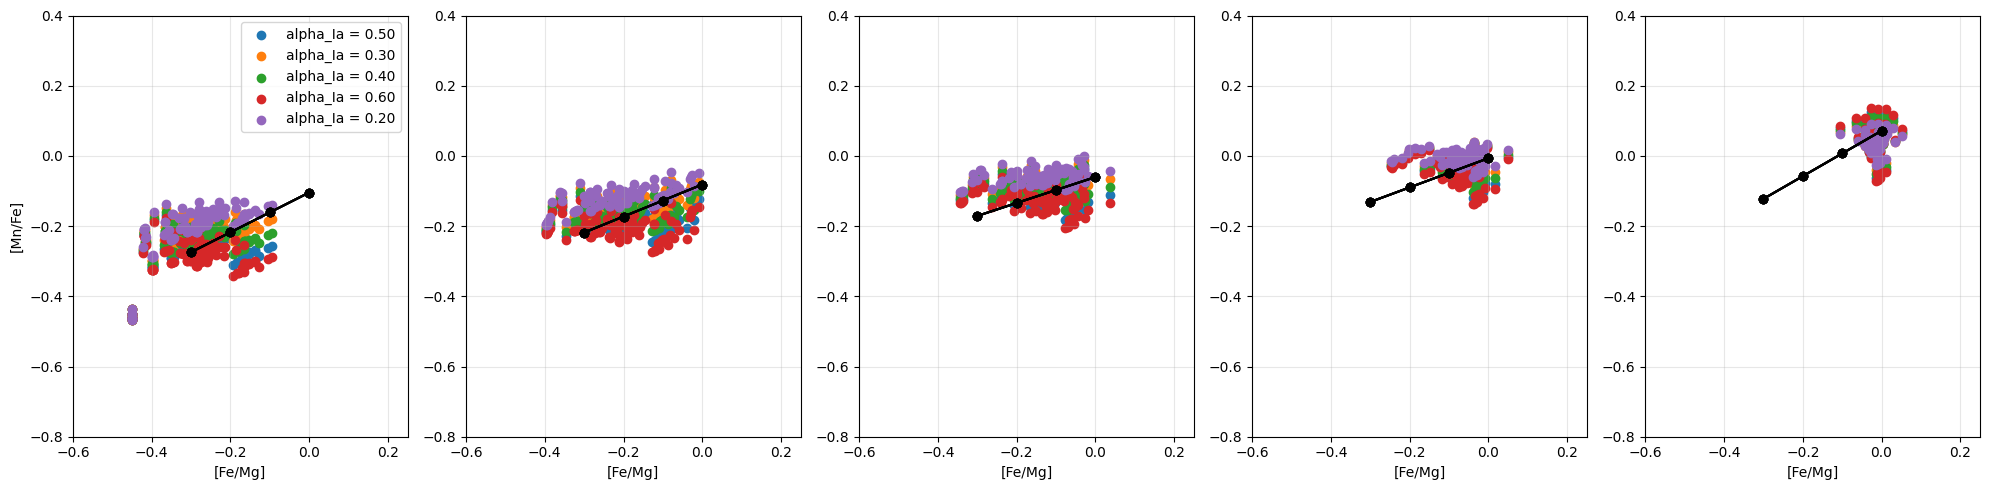

In [28]:
filepath_list = []
output_dfs = []

for filename in os.listdir(folder_path):
    if filename.startswith("alpha_Ia_iter1") and filename.endswith(".csv"):
        filepath_list.append(folder_path+filename)
        df = pd.read_csv(folder_path+filename)
        output_dfs.append(df)


plt.figure(figsize=(20,5))

for i in range(len(output_dfs)):
    model_df = output_dfs[i]
    mg_h_bins = model_df['mg_h_bin'].unique()
    for j in range(len(mg_h_bins)):
        mg_h_bin = mg_h_bins[j]
        model_subset = model_df[np.isclose(model_df['mg_h_bin'], mg_h_bin)]
        data_subset = data[np.isclose(data['mg_h_bin_center'], mg_h_bin)]
        data_line_xs = fe_mg_centers
        data_line_ys = data_subset['slope_mn_fe'].iloc[0] * fe_mg_centers + data_subset['intercept_mn_fe'].iloc[0]
        plt.subplot(1,5,j+1)
        plt.plot(data_line_xs, data_line_ys, marker = 'o', color = 'black')
        plt.scatter(model_subset['fe_mg'], model_subset['mn_fe'], label = f'alpha_Ia = {model_subset['alpha_Ia'].iloc[0]:.2f}')
        plt.xlim(-0.60, 0.25)
        plt.ylim(-0.8, 0.40)
        plt.grid(True, alpha = 0.3)
        plt.xlabel("[Fe/Mg]")
        if j == 0:
            plt.ylabel("[Mn/Fe]")
            plt.legend()

plt.tight_layout()
plt.show()

In [29]:
iterative_1D_method.iterative_1D_loop(data_path="data_lines_with_vals.csv", output_path="penalty_3/",
                                      n_iters=5, grid_size=0.1, grid_len=5, alpha_cc_init=0.3,
                                      alpha_Ia_init=0.4, g_cc_init=0.4, g_ratio_init=1.8, etas=etas_alter, tau_stars=tau_stars_alter)

alpha_ccs =  [0.1 0.2 0.3 0.4 0.5]
n_gals in each alpha_cc =  108
n_gals total =  540
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
iter = 0
best alpha_cc = 0.3
alpha_Ias =  [0.2 0.3 0.4 0.5 0.6]
n_gals in each alpha_Ia =  108
n_gals total =  540
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
iter = 0
best alpha_Ia = 0.4


In [30]:
iterative_1D_method.iterative_1D_loop(data_path="data_lines_with_vals.csv", output_path="penalty_diff_start/",
                                      n_iters=5, grid_size=0.1, grid_len=5, alpha_cc_init=0.6,
                                      alpha_Ia_init=0.4, g_cc_init=0.4, g_ratio_init=1.8, etas=etas_alter, tau_stars=tau_stars_alter)

alpha_ccs =  [0.4 0.5 0.6 0.7 0.8]
n_gals in each alpha_cc =  108
n_gals total =  540
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
iter = 0
best alpha_cc = 0.3999999999999999
alpha_Ias =  [0.2 0.3 0.4 0.5 0.6]
n_gals in each alpha_Ia =  108
n_gals total =  540
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
iter = 0
best 

In [32]:
best_per_iter = pd.read_csv("penalty_diff_start/best_parameters_per_iteration.csv")
best_per_iter

,iteration,best_alpha_cc,best_alpha_Ia,best_g_cc,best_g_ratio
0,0,0.4,0.4,0.4,1.8
1,0,0.4,0.3,0.4,1.8
2,0,0.4,0.3,0.4,1.8
3,0,0.4,0.3,0.4,1.7
4,1,0.4,0.3,0.4,1.7
5,1,0.4,0.3,0.4,1.7
6,1,0.4,0.3,0.4,1.7
7,1,0.4,0.3,0.4,1.7
8,2,0.4,0.3,0.4,1.7
9,2,0.4,0.3,0.4,1.7


In [42]:
iterative_1D_method.iterative_1D_loop(data_path="data_lines_with_vals.csv", output_path="penalty_diff_start_2/",
                                      n_iters=5, grid_size=0.1, grid_len=5, alpha_cc_init=0.3,
                                      alpha_Ia_init=0.8, g_cc_init=0.4, g_ratio_init=1.8, etas=etas_alter, tau_stars=tau_stars_alter)

best_per_iter = pd.read_csv("penalty_diff_start_2/best_parameters_per_iteration.csv")
best_per_iter

alpha_ccs =  [0.1 0.2 0.3 0.4 0.5]
n_gals in each alpha_cc =  108
n_gals total =  540
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
iter = 0
best alpha_cc = 0.1999999999999999
alpha_Ias =  [0.6 0.7 0.8 0.9 1. ]
n_gals in each alpha_Ia =  108
n_gals total =  432
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
iter = 0
best 

,iteration,best_alpha_cc,best_alpha_Ia,best_g_cc,best_g_ratio
0,0,0.2,0.8,0.4,1.8
1,0,0.2,0.7,0.4,1.8
2,0,0.2,0.7,0.4,1.8
3,0,0.2,0.7,0.4,1.8
4,1,0.3,0.7,0.4,1.8
5,1,0.3,0.5,0.4,1.8
6,1,0.3,0.5,0.4,1.8
7,1,0.3,0.5,0.4,1.8
8,2,0.3,0.5,0.4,1.8
9,2,0.3,0.4,0.4,1.8


In [43]:
iterative_1D_method.iterative_1D_loop(data_path="data_lines_with_vals.csv", output_path="penalty_diff_start_3/",
                                      n_iters=5, grid_size=0.1, grid_len=5, alpha_cc_init=0.3,
                                      alpha_Ia_init=0.4, g_cc_init=0.4, g_ratio_init=1.8, etas=etas_alter, tau_stars=tau_stars_alter)

best_per_iter = pd.read_csv("penalty_diff_start_3/best_parameters_per_iteration.csv")
best_per_iter

alpha_ccs =  [0.1 0.2 0.3 0.4 0.5]
n_gals in each alpha_cc =  108
n_gals total =  540
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
iter = 0
best alpha_cc = 0.3
alpha_Ias =  [0.2 0.3 0.4 0.5 0.6]
n_gals in each alpha_Ia =  108
n_gals total =  540
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
iter = 0
best alpha_Ia = 0.4


,iteration,best_alpha_cc,best_alpha_Ia,best_g_cc,best_g_ratio
0,0,0.3,0.4,0.4,1.8
1,0,0.3,0.4,0.4,1.8
2,0,0.3,0.4,0.4,1.8
3,0,0.3,0.4,0.4,1.7
4,1,0.3,0.4,0.4,1.7
5,1,0.3,0.4,0.4,1.7
6,1,0.3,0.4,0.4,1.7
7,1,0.3,0.4,0.4,1.7
8,2,0.3,0.4,0.4,1.7
9,2,0.3,0.4,0.4,1.7


In [44]:
iterative_1D_method.iterative_1D_loop(data_path="data_lines_with_vals.csv", output_path="penalty_diff_start_4/",
                                      n_iters=5, grid_size=0.1, grid_len=5, alpha_cc_init=0.4,
                                      alpha_Ia_init=0.4, g_cc_init=0.4, g_ratio_init=1.8, etas=etas_alter, tau_stars=tau_stars_alter)

best_per_iter = pd.read_csv("penalty_diff_start_4/best_parameters_per_iteration.csv")
best_per_iter

alpha_ccs =  [0.2 0.3 0.4 0.5 0.6]
n_gals in each alpha_cc =  108
n_gals total =  540
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
iter = 0
best alpha_cc = 0.3
alpha_Ias =  [0.2 0.3 0.4 0.5 0.6]
n_gals in each alpha_Ia =  108
n_gals total =  540
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
iter = 0
best alpha_Ia = 0.4


,iteration,best_alpha_cc,best_alpha_Ia,best_g_cc,best_g_ratio
0,0,0.3,0.4,0.4,1.8
1,0,0.3,0.4,0.4,1.8
2,0,0.3,0.4,0.4,1.8
3,0,0.3,0.4,0.4,1.7
4,1,0.3,0.4,0.4,1.7
5,1,0.3,0.4,0.4,1.7
6,1,0.3,0.4,0.4,1.7
7,1,0.3,0.4,0.4,1.7
8,2,0.3,0.4,0.4,1.7
9,2,0.3,0.4,0.4,1.7


In [46]:
iterative_1D_method.iterative_1D_loop(data_path="data_lines_with_vals.csv", output_path="penalty_diff_start_5/",
                                      n_iters=5, grid_size=0.1, grid_len=5, alpha_cc_init=0.4,
                                      alpha_Ia_init=0.3, g_cc_init=0.4, g_ratio_init=1.8, etas=etas_alter, tau_stars=tau_stars_alter)

best_per_iter = pd.read_csv("penalty_diff_start_5/best_parameters_per_iteration.csv")
best_per_iter

alpha_ccs =  [0.2 0.3 0.4 0.5 0.6]
n_gals in each alpha_cc =  108
n_gals total =  540
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
iter = 0
best alpha_cc = 0.4
alpha_Ias =  [0.1 0.2 0.3 0.4 0.5]
n_gals in each alpha_Ia =  108
n_gals total =  540
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
iter = 0
best alpha_Ia = 0.3


,iteration,best_alpha_cc,best_alpha_Ia,best_g_cc,best_g_ratio
0,0,0.4,0.3,0.4,1.8
1,0,0.4,0.3,0.4,1.8
2,0,0.4,0.3,0.4,1.8
3,0,0.4,0.3,0.4,1.7
4,1,0.4,0.3,0.4,1.7
5,1,0.4,0.3,0.4,1.7
6,1,0.4,0.3,0.4,1.7
7,1,0.4,0.3,0.4,1.7
8,2,0.4,0.3,0.4,1.7
9,2,0.4,0.3,0.4,1.7


In [48]:
iterative_1D_method.iterative_1D_loop(data_path="data_lines_with_vals.csv", output_path="penalty_diff_start_6/",
                                      n_iters=5, grid_size=0.1, grid_len=5, alpha_cc_init=0.4,
                                      alpha_Ia_init=0.3, g_cc_init=0.4, g_ratio_init=1.2, etas=etas_alter, tau_stars=tau_stars_alter)

best_per_iter = pd.read_csv("penalty_diff_start_6/best_parameters_per_iteration.csv")
best_per_iter

alpha_ccs =  [0.2 0.3 0.4 0.5 0.6]
n_gals in each alpha_cc =  108
n_gals total =  540
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
iter = 0
best alpha_cc = 0.3
alpha_Ias =  [0.1 0.2 0.3 0.4 0.5]
n_gals in each alpha_Ia =  108
n_gals total =  540
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
iter = 0
best alpha_Ia = 0.09

,iteration,best_alpha_cc,best_alpha_Ia,best_g_cc,best_g_ratio
0,0,0.3,0.3,0.4,1.2
1,0,0.3,0.1,0.4,1.2
2,0,0.3,0.1,0.4,1.2
3,0,0.3,0.1,0.4,1.3
4,1,0.4,0.1,0.4,1.3
5,1,0.4,0.1,0.4,1.3
6,1,0.4,0.1,0.4,1.3
7,1,0.4,0.1,0.4,1.5
8,2,0.4,0.1,0.4,1.5
9,2,0.4,0.2,0.4,1.5


In [45]:
iterative_1D_method.iterative_1D_loop(data_path="data_lines_with_vals.csv", output_path="penalty_diff_start_7/",
                                      n_iters=5, grid_size=0.1, grid_len=5, alpha_cc_init=0.4,
                                      alpha_Ia_init=0.3, g_cc_init=0.8, g_ratio_init=1.8, etas=etas_alter, tau_stars=tau_stars_alter)

best_per_iter = pd.read_csv("penalty_diff_start_7/best_parameters_per_iteration.csv")
best_per_iter

alpha_ccs =  [0.2 0.3 0.4 0.5 0.6]
n_gals in each alpha_cc =  108
n_gals total =  540
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
iter = 0
best alpha_cc = 0.6000000000000001
alpha_Ias =  [0.1 0.2 0.3 0.4 0.5]
n_gals in each alpha_Ia =  108
n_gals total =  540
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
iter = 0
best 

,iteration,best_alpha_cc,best_alpha_Ia,best_g_cc,best_g_ratio
0,0,0.6,0.3,0.8,1.8
1,0,0.6,0.5,0.8,1.8
2,0,0.6,0.5,0.6,1.8
3,0,0.6,0.5,0.6,1.6
4,1,0.7,0.5,0.6,1.6
5,1,0.7,0.5,0.6,1.6
6,1,0.7,0.5,0.6,1.6
7,1,0.7,0.5,0.6,1.4
8,2,0.6,0.5,0.6,1.4
9,2,0.6,0.5,0.6,1.4
